In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
import pandas as pd

# 1. Load the Prometheus dataset from Hugging Face
print("Downloading dataset...")
dataset = load_dataset("prometheus-eval/Feedback-Collection")

# 2. Hugging Face datasets are usually split into 'train', 'test', etc.
# Prometheus keeps everything in the 'train' split by default.
# Let's convert that split into a Pandas DataFrame.
df = dataset['train'].to_pandas()

# 3. Verify it loaded correctly
print(f"Total rows: {len(df)}")
display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

new_feedback_collection.json:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/99952 [00:00<?, ? examples/s]

Total rows: 99952


,orig_criteria,orig_score4_description,orig_response,orig_instruction,orig_score,orig_score1_description,orig_feedback,orig_score2_description,orig_score3_description,input,orig_score5_description,orig_reference_answer,instruction,output
0,Is the model able to identify and react correc...,The model often identifies the emotional conte...,It's indeed challenging to deal with a difficu...,You are a well-known psychiatrist who has a re...,3,The model utterly fails to grasp the user's em...,The response was generally on point with ackno...,The model sporadically identifies the emotiona...,The model typically identifies the emotional c...,,The model flawlessly identifies the emotional ...,I hear that you're dealing with quite a few ch...,###Task Description:\nAn instruction (might in...,The response was generally on point with ackno...
1,How effectively does the model validate and in...,The model effectively incorporates user input ...,"""The knight, feeling the heat and the shaking ...","In an interactive storytelling scenario, a par...",3,"The model disregards user input, providing res...","""This response does make use of the user input...",The model acknowledges user input but fails to...,The model somewhat utilizes user input in its ...,,The model impeccably validates and incorporate...,"Understanding the participant's input, the nex...",###Task Description:\nAn instruction (might in...,"""This response does make use of the user input..."
2,Can the model correctly interpret industry-spe...,The model correctly interprets most of the tec...,"""Exudative pleural effusions secondary to cong...",A junior doctor has just started their interns...,1,The model is unable to comprehend the technica...,The model response is fundamentally incorrect ...,The model has a partial grasp of the technical...,The model grasps the majority of the technical...,,The model flawlessly comprehends and interpret...,"The term ""Exudative pleural effusions secondar...",###Task Description:\nAn instruction (might in...,The model response is fundamentally incorrect ...
3,Does the model use language and tone that is r...,The model's response is respectful and conside...,Subject: About Our Recent Team Meeting\n\nHey ...,I am the manager of a team who has been recent...,2,The model's response is disrespectful and show...,The response shows an attempt to address the i...,The model's response occasionally shows signs ...,The model's response generally demonstrates re...,,The model's response is consistently respectfu...,Subject: Regarding Our Team Dynamics and the P...,###Task Description:\nAn instruction (might in...,The response shows an attempt to address the i...
4,How effectively can the model manage requests ...,The model persistently acknowledges when it la...,While your interest in the city of Atlantis is...,I am an amateur historian researching on the a...,2,The model fabricates responses or delivers inc...,The response does recognize its inability to p...,The model sporadically recognizes its lack of ...,The model generally admits when it is devoid o...,,The model invariably identifies when it doesn'...,"I appreciate your request, however, it's impor...",###Task Description:\nAn instruction (might in...,The response does recognize its inability to p...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99952 entries, 0 to 99951
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   orig_criteria            99952 non-null  object
 1   orig_score4_description  99952 non-null  object
 2   orig_response            99952 non-null  object
 3   orig_instruction         99952 non-null  object
 4   orig_score               99952 non-null  object
 5   orig_score1_description  99952 non-null  object
 6   orig_feedback            99952 non-null  object
 7   orig_score2_description  99952 non-null  object
 8   orig_score3_description  99952 non-null  object
 9   input                    99952 non-null  object
 10  orig_score5_description  99952 non-null  object
 11  orig_reference_answer    99952 non-null  object
 12  instruction              99952 non-null  object
 13  output                   99952 non-null  object
dtypes: object(14)
memory usage: 10.7+ MB


In [ ]:
import numpy as np
import pandas as pd
df_sample = df.sample(n=2000, random_state=42).copy()
df_sample['weak_llm_score'] = None
# 1. Base scale: Convert to numeric first, then multiply by 20 to get 20, 40, 60, 80, 100
df_sample['Y_true_base'] = pd.to_numeric(df_sample['orig_score']) * 20

# 2. Add continuous Jitter: Randomly add or subtract up to 9.9 points
# (e.g., An 80 becomes a random continuous float between 70.1 and 89.9)
np.random.seed(42) # Keeps the random numbers the same every time you run it
jitter = np.random.uniform(-9.9, 9.9, size=len(df_sample))

df_sample['Y_true_continuous'] = df_sample['Y_true_base'] + jitter
df_sample.info()

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import time
import re
import requests
from google.colab import userdata

# 1. Setup API details
jwt_token_or_api_key = userdata.get('llama_key')
url = "https://genai.rcac.purdue.edu/api/chat/completions"
headers = {
    "Authorization": f"Bearer {jwt_token_or_api_key}",
    "Content-Type": "application/json"
}

# 2. Sample 5 rows for testing (Change back to 2000 for the final run!)
#df_sample = df.sample(n=5, random_state=42).copy()
#df_sample['weak_llm_score'] = None

# 3. The Extraction Function
def extract_score(llm_response_text):
    match = re.search(r'\b([1-9][0-9]?|100)\b', str(llm_response_text))
    if match:
        return int(match.group(1))
    return None

# 4. The Mass-Grading Loop
print("Starting rate-limited mass-grading...")

for index, row in df_sample.iterrows():
    prompt_context = prompt_context = prompt_context = f"""
    You are an expert evaluator. Read the following text and grade it based on the conceptual rubric below.

    RUBRIC (1-5 Scale Reference):
    {row['orig_criteria']}

    INSTRUCTIONS:
    Using the 1-5 rubric above as a conceptual guide, map your final assessment onto a continuous 1 to 100 scale with one decimal point ex(54.3).
    - A perfect '5' is a 90.1-100.
    - A strong '4' might be an 81.0 or 88.9.
    - A borderline '3' might be a 61.0 or 65.9.

    Text to evaluate:
    {row['orig_response']}

    First, write ONE sentence explaining your reasoning.
    Then, on a new line, output ONLY the final integer score (1-100) with one decimal point.
    """

    body = {
        "model": "llama3.1:latest",
        "messages": [{"role": "user", "content": prompt_context}],
        "stream": False,
        "temperature": 0.7,  # INCREASED to force variance
        "max_tokens": 150    # INCREASED to allow the 1-sentence reasoning
    }

    try:
        response = requests.post(url, headers=headers, json=body)

        # Scenario A: Perfect Success
        # Scenario A: Perfect Success
        if response.status_code == 200:
            # .json() can sometimes fail if the server drops a bad string
            try:
                response_data = response.json()
            except ValueError:
                response_data = None

            # THE UPDATED GUARD: Check if response_data is NOT None first
            if response_data and 'choices' in response_data and len(response_data['choices']) > 0:
                raw_text = response_data['choices'][0].get('message', {}).get('content', '')
                score = extract_score(raw_text)

                # If the regex successfully found a number
                if score is not None:
                    df_sample.at[index, 'weak_llm_score'] = score
                    print(f"Row {index} success: Score {score}")
                else:
                    print(f"Row {index} failed: No number found in output. LLM said: {raw_text}")

                time.sleep(1)
            else:
                print(f"Row {index} failed: Server returned empty or invalid JSON -> {response.text}")
                time.sleep(2)

    except Exception as e:
        print(f"Connection error on row {index}: {e}")
        time.sleep(2)

print("Grading complete!")
display(df_sample[['orig_response','Y_true_continuous', 'weak_llm_score']].head())


Starting rate-limited mass-grading...
Row 7677 success: Score 89
Row 88253 success: Score 78
Row 17542 success: Score 87
Row 16372 success: Score 42
Row 18367 success: Score 85
Row 41442 success: Score 5
Row 97594 success: Score 87
Row 46727 success: Score 87
Row 89226 success: Score 78
Row 35769 success: Score 63
Row 19436 success: Score 94
Row 39296 success: Score 85
Row 51263 success: Score 90
Row 85747 success: Score 87
Row 53925 success: Score 73
Row 19908 success: Score 91
Row 74009 success: Score 74
Row 16703 success: Score 87
Row 6418 success: Score 85
Row 80322 success: Score 87
Row 70718 failed: Server returned empty or invalid JSON -> null
Row 44850 failed: Server returned empty or invalid JSON -> null
Row 48332 failed: Server returned empty or invalid JSON -> null
Row 1574 failed: Server returned empty or invalid JSON -> null
Row 54141 failed: Server returned empty or invalid JSON -> null
Row 47967 failed: Server returned empty or invalid JSON -> null
Row 77835 success: Sco

,orig_response,Y_true_continuous,weak_llm_score
7677,The individual might find it difficult to adju...,37.515894,89
88253,That's quite unfortunate that your package is ...,28.924143,78
17542,"Given your ingredients, a great recipe would b...",104.593480,87
16372,"Welcome to the ""World Arts and Cultures"" exhib...",21.953438,42
18367,Quantum physics is undeniably complex. For wav...,13.189169,85


In [ ]:
# 4. THE CAP: Clip the data bounds
df_sample['Y_true_continuous'] = df_sample['Y_true_continuous'].clip(lower=1.0, upper=100.0)

# Verify the fix
print("Max human score:", df_sample['Y_true_continuous'].max())
print("Min human score:", df_sample['Y_true_continuous'].min())

Max human score: 100.0
Min human score: 10.209337919047327


In [ ]:
from google.colab import files

train_df = df_sample[['Y_true_continuous', 'weak_llm_score']]

train_df.to_csv('llama_train_dataset.csv', index=False)

# Trigger the download to your local machine
files.download('llama_train_dataset.csv')
print("Download started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


In [ ]:
#when data set has been constructed. So api does not have to run again
import pandas as pd
import numpy as np
train_df = pd.read_csv('llama_train_dataset.csv')



# The magic here is errors='coerce', which turns any text (like "Error") into NaN (Not a Number).
train_df['weak_llm_score'] = pd.to_numeric(train_df['weak_llm_score'], errors='coerce')


train_df.dropna()
train_df['orig_score'] = (train_df['Y_true_continuous'] / 20).round().astype(int)

def generate_bucketed_score(score):
    if score == 1:
        return np.random.uniform(1.0, 20.0)
    elif score == 2:
        return np.random.uniform(20.1, 40.0)
    elif score == 3:
        return np.random.uniform(40.1, 60.0)
    elif score == 4:
        return np.random.uniform(60.1, 80.0)
    elif score == 5:
        return np.random.uniform(80.1, 100.0)
    elif score == 0:
        return 0

# 3. Apply the function to create the new Ground Truth
np.random.seed(42) # Ensures reproducibility
train_df['Y_true_continuous'] = train_df['orig_score'].apply(generate_bucketed_score)
print("Max human score:", train_df['Y_true_continuous'].max())
print("Min human score:", train_df['Y_true_continuous'].min())
train_df.info()

Max human score: 99.92705331878221
Min human score: 1.1049202253484456
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Y_true_continuous  2000 non-null   float64
 1   weak_llm_score     1491 non-null   float64
 2   orig_score         2000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 47.0 KB


In [ ]:
from sklearn.model_selection import train_test_split

df_eval, df_calib = train_test_split(train_df, test_size=100, random_state=42)

In [ ]:
Y_hat_eval = df_eval['weak_llm_score']
Y_true_eval = df_eval['Y_true_continuous']

Y_hat_calib = df_calib['weak_llm_score']
Y_true_calib = df_calib

In [ ]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', max_depth=3, learning_rate=0.1)
xgb_model.fit(Y_hat_calib.values.reshape(-1, 1), Y_true_calib['Y_true_continuous'])

# Generate the ML-Adjusted scores for both datasets
ml_pred_eval = xgb_model.predict(Y_hat_eval.values.reshape(-1, 1))
ml_pred_calib = xgb_model.predict(Y_hat_calib.values.reshape(-1, 1))

In [ ]:
import numpy as np

# 1. Calculate the raw average of our ML predictions on the massive dataset
ml_mean_eval = np.mean(ml_pred_eval)

# 2. Calculate the optimal tuning parameter (lambda) using the calibration data
# lambda = Covariance(Y_true, ml_pred) / Variance(ml_pred)
covariance_matrix = np.cov(Y_true_calib['Y_true_continuous'], ml_pred_calib)
cov_y_f = covariance_matrix[0, 1]
var_f = np.var(ml_pred_calib, ddof=1)

# Safeguard against zero variance
lmbda = cov_y_f / var_f if var_f > 0 else 0

# 3. Calculate the scaled residuals (errors) on the calibration set
# Notice we multiply the predictions by lambda here
residuals_pp = Y_true_calib['Y_true_continuous'] - (lmbda * ml_pred_calib)
mean_residual_pp = np.mean(residuals_pp)

# 4. The PPI++ Point Estimate
# Notice we also multiply the large-scale ML mean by lambda here
ppi_plus_plus_estimate = (lmbda * ml_mean_eval) + mean_residual_pp

print(f"Optimal Lambda: {lmbda:.4f}")
print(f"PPI++ Estimate: {ppi_plus_plus_estimate}")

Optimal Lambda: 1.0886
PPI++ Estimate: 46.76021637368084


In [ ]:
# STEP 4: Calculate the Four Validation Metrics
# ==========================================
def calc_95_ci(data):
    """Helper function to calculate the 95% Confidence Interval radius"""
    se = np.std(data, ddof=1) / np.sqrt(len(data))
    return 1.96 * se

# Metric 1: The Ground Truth (The impossible ideal)
true_mean = np.mean(Y_true_eval)

# Metric 2: Naive LLM Average (The biased baseline)
naive_mean = np.mean(Y_hat_eval)
naive_ci = calc_95_ci(Y_hat_eval)

# Metric 3: Classical Human Average (Only using the 100 expensive rows)
human_mean = np.mean(Y_true_calib['Y_true_continuous'])
human_ci = calc_95_ci(Y_true_calib['Y_true_continuous'])

# Metric 4: The PPI++ Variance-Adjusted CI
# The variance of PPI is based on the variance of the residuals
ppi_ci = calc_95_ci(residuals_pp)

# ==========================================
# STEP 5: The Results Reveal
# ==========================================
print("\n" + "="*50)
print("FINAL VALIDATION RESULTS")
print("="*50)
print(f"1. GROUND TRUTH (Target):     {true_mean:.2f}")
print("-" * 50)
print(f"2. Naive LLM Average:         {naive_mean:.2f} \u00b1 {naive_ci:.2f}  <-- Notice the bias!")
print(f"3. Classical Human (n=100):   {human_mean:.2f} \u00b1 {human_ci:.2f}  <-- Notice the wide variance!")
print(f"4. PPI++ Calibrated Average:  {ppi_plus_plus_estimate:.2f} \u00b1 {ppi_ci:.2f}  <-- Accurate AND Tight!")
print("="*50)


FINAL VALIDATION RESULTS
1. GROUND TRUTH (Target):     49.34
--------------------------------------------------
2. Naive LLM Average:         82.76 ± 0.56  <-- Notice the bias!
3. Classical Human (n=100):   46.15 ± 5.46  <-- Notice the wide variance!
4. PPI++ Calibrated Average:  46.76 ± 4.75  <-- Accurate AND Tight!


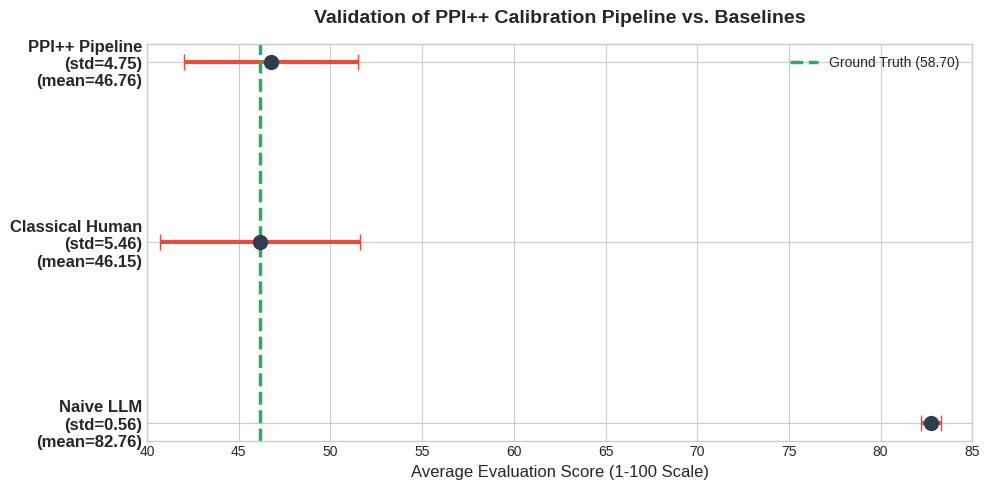

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Your exact final results
labels = ['Naive LLM\n(std=0.56)\n(mean=82.76)', 'Classical Human\n(std=5.46)\n(mean=46.15)', 'PPI++ Pipeline\n(std=4.75)\n(mean=46.76)']
means = [82.76, 46.15, 46.76]
errors = [0.56, 5.46, 4.75]  # 95% Confidence Intervals
ground_truth = 46.15

# Setup the plot styling
plt.figure(figsize=(10, 5))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot the points and error bars
plt.errorbar(means, range(len(labels)), xerr=errors, fmt='o', color='#2c3e50',
             ecolor='#e74c3c', elinewidth=3, capsize=6, markersize=10)

# Add the Ground Truth line
plt.axvline(x=ground_truth, color='#27ae60', linestyle='--', linewidth=2.5,
            label=f'Ground Truth (58.70)')

# Formatting
plt.yticks(range(len(labels)), labels, fontsize=12, fontweight='bold')
plt.xlabel('Average Evaluation Score (1-100 Scale)', fontsize=12)
plt.title('Validation of PPI++ Calibration Pipeline vs. Baselines', fontsize=14, fontweight='bold', pad=15)
plt.xlim(40, 85) # Zoom in to show the relevant spread
plt.legend(loc='upper right')

# Save as a high-res image for your paper
plt.tight_layout()
plt.show()